In [2]:
!pip install icrawler

In [5]:
!pip install torch torchvision
!pip install git+https://github.com/openai/CLIP.git
!pip install sentence-transformers

   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.2 MB 660.6 kB/s eta 0:00:10
   ---------------------------------------- 0.0/6.2 MB 660.6 kB/s eta 0:00:10
   ---------------------------------------- 0.1/6.2 MB 491.5 kB/s eta 0:00:13
   ---------------------------------------- 0.1/6.2 MB 491.5 kB/s eta 0:00:13
   ---------------------------------------- 0.1/6.2 MB 491.5 kB/s eta 0:00:13
    --------------------------------------- 0.1/6.2 MB 347.8 kB/s eta 0:00:18
    --------------------------------------- 0.1/6.2 MB 347.8 kB/s eta 0:00:18
    --------------------------------------- 0.1/6.2 MB 347.8 kB/s eta 0:00:18
    --------------------------------------- 0.1/6.2 MB 327.9 kB/s eta 0:00:19
    --------------------------------------- 0.2/6.2 MB 328.1 kB/s eta 0:00:19
   - -------------------------------------- 0.2/6.2 MB 348.2 kB/s eta 0:00:18
   - -------------------------------------- 0.2/6.2 MB 355.7 kB/s eta 0:0

  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\Anagha S Shastri\AppData\Local\Temp\pip-req-build-f_gn9w0w'


     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     -------------------------------------- 41.5/41.5 kB 664.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/512.4 kB ? eta -:--:--
    --------------------------------------- 10.2/512.4 kB ? eta -:--:--
   --- ----------------------------------- 41.0/512.4 kB 393.8 kB/s eta 0:00:02
   ----- --------------------------------- 71.7/512.4 kB 491.5 kB/s eta 0:00:01
   ------- ------------------------------- 92.2/512.4 kB 525.1 kB/s eta 0:00:01
   ------- ------------------------------ 102.4/512.4 kB 490.2 kB/s eta 0:00:01
   ---------- --------------------------- 143.4/512.4 kB 500.5 kB/s eta 0:00:01
   ----------- -------------------------- 153.6/512.4 kB 482.7 kB/s eta 0:00:01
   ------------- ------------------------ 184.3/512.4 kB 484.9 kB/s eta 0:00:01
   --------------- ---------------------- 204.8/512.4 kB 497.6 kB/s eta 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 6.33.5 which is incompatible.


In [ ]:
#Download images automatically using crawler

from icrawler.builtin import BingImageCrawler

crawler = BingImageCrawler(storage={'root_dir': r'D:\Lost_and_Found\data\images\bags'})
crawler.crawl(keyword='backpack', max_num=20)

crawler = BingImageCrawler(storage={'root_dir': r'D:\Lost_and_Found\data\images\bottles'})
crawler.crawl(keyword='water bottle', max_num=20)

crawler = BingImageCrawler(storage={'root_dir': r'D:\Lost_and_Found\data\images\earpods'})
crawler.crawl(keyword='earpods', max_num=20)

crawler = BingImageCrawler(storage={'root_dir': r'D:\Lost_and_Found\data\images\headphones'})
crawler.crawl(keyword='headphones', max_num=20)

crawler = BingImageCrawler(storage={'root_dir': r'D:\Lost_and_Found\data\images\aadharcards'})
crawler.crawl(keyword='aadhaar card', max_num=20)

2026-03-29 14:32:39,707 - INFO - icrawler.crawler - start crawling...


2026-03-29 14:32:39,709 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-03-29 14:32:39,711 - INFO - feeder - thread feeder-001 exit
2026-03-29 14:32:39,729 - INFO - icrawler.crawler - starting 1 parser threads...
2026-03-29 14:32:39,736 - INFO - icrawler.crawler - starting 1 downloader threads...
2026-03-29 14:32:41,274 - INFO - parser - parsing result page https://www.bing.com/images/async?q=backpack&first=0
2026-03-29 14:32:44,416 - ERROR - downloader - Response status code 404, file https://www.gp-award.com/assets/media/products/modularer-outdoor-rucksack/372_productLarge.jpg
2026-03-29 14:32:49,377 - INFO - downloader - image #1	https://www.ttlbags.com/wp-content/uploads/2023/06/School-Bag-TL-SC09.jpg
2026-03-29 14:32:50,715 - INFO - downloader - image #2	https://image.chukouplus.com/upload/C_1995/file/20220919/05a4dee83d99c93ed1024d613c6426fd.jpg
2026-03-29 14:32:53,150 - INFO - downloader - image #3	https://www.mrbackpacks.com/wp-content/uploads/2022/07/TSNGCOOL-Wat

In [ ]:
#Auto-create metadata.json

import os
import json

data = []

base_path = r"D:\Lost_and_Found\data\images"

for category in os.listdir(base_path):
    folder_path = os.path.join(base_path, category)
    
    for file in os.listdir(folder_path):
        if file.endswith(".jpg") or file.endswith(".png"):
            data.append({
                "image": f"{category}/{file}",
                "text": category  # simple label
            })

# Save JSON
with open(r"D:\Lost_and_Found\data\metadata.json", "w") as f:
    json.dump(data, f, indent=4)

print("Metadata created!")

Metadata created!


In [24]:
#Image embedding

import torch
import clip
from PIL import Image

model, preprocess = clip.load("ViT-B/32")

def get_image_embedding(image_path):
    try:
        image = Image.open(image_path).convert("RGB")  # IMPORTANT FIX
        image = preprocess(image).unsqueeze(0)

        with torch.no_grad():
            emb = model.encode_image(image)

        emb = emb / emb.norm(dim=-1, keepdim=True)
        return emb.cpu().numpy()[0]

    except Exception as e:
        print("Error loading:", image_path)
        raise e

In [25]:
#Text embedding

from sentence_transformers import SentenceTransformer

text_model = SentenceTransformer('all-MiniLM-L6-v2')

def get_text_embedding(text):
    return text_model.encode(text, normalize_embeddings=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
#Cosine Similarity Function

from sklearn.metrics.pairwise import cosine_similarity

def similarity(vec1, vec2):
    vec1 = vec1.reshape(1, -1)
    vec2 = vec2.reshape(1, -1)
    return cosine_similarity(vec1, vec2)[0][0]

In [27]:
#Fusion logic

def final_score(img_sim, text_sim):
    return 0.7 * img_sim + 0.3 * text_sim

In [28]:
#Load metadata

import json

with open(r"D:\Lost_and_Found\data\metadata.json") as f:
    items = json.load(f)

In [43]:
#CREATE MATCHING FUNCTION (CORE)

def find_matches(query_img_path, query_text, category=None):
    results = []

    # Query embeddings
    query_img_emb = get_image_embedding(query_img_path)
    query_text_emb = get_text_embedding(query_text)

    for item in items:
        if category and item["text"] != category:
            continue
        
        img_path = r"D:\Lost_and_Found\data\images/" + item["image"]
        text = item["text"]

        try:
            img_emb = get_image_embedding(img_path)
            text_emb = get_text_embedding(text)

            img_sim = similarity(query_img_emb, img_emb)
            text_sim = similarity(query_text_emb, text_emb)

            score = final_score(img_sim, text_sim)

            results.append({
                "image": item["image"],
                "score": score
            })

        except Exception as e:
            print("Error:", img_path, e)

    # Sort results (highest score first)
    results = sorted(results, key=lambda x: x["score"], reverse=True)

    return results

In [44]:
#Testing the model

results = find_matches(
    r"D:\Lost_and_Found\data\images\bags\000001.jpg",
    "black backpack", category="bags"
)

for r in results[:]:
    print(r)

{'image': 'bags/000001.jpg', 'score': 0.6400138914585114}
{'image': 'bags/000013.jpg', 'score': 0.5837072312831879}
{'image': 'bags/000011.jpg', 'score': 0.5703506350517273}
{'image': 'bags/000010.jpg', 'score': 0.5700321972370148}
{'image': 'bags/000009.jpg', 'score': 0.5643865048885346}
{'image': 'bags/000014.jpg', 'score': 0.5328499853610993}
{'image': 'bags/000016.jpg', 'score': 0.5306714653968811}
{'image': 'bags/000005.jpg', 'score': 0.5292681336402894}
{'image': 'bags/000006.jpg', 'score': 0.5205465137958527}
{'image': 'bags/000008.jpg', 'score': 0.5180523872375489}
{'image': 'bags/000012.jpg', 'score': 0.5177635133266449}
{'image': 'bags/000007.jpg', 'score': 0.5128718197345734}
{'image': 'bags/000004.jpg', 'score': 0.5128658592700959}
{'image': 'bags/000002.jpg', 'score': 0.5087092399597168}
{'image': 'bags/000015.jpg', 'score': 0.45211912989616393}
{'image': 'bags/000003.jpg', 'score': 0.4391725242137909}


In [45]:
#showing images

import matplotlib.pyplot as plt
from PIL import Image

def show_results(results, top_k=3):
    for r in results[:top_k]:
        img_path = r"D:\Lost_and_Found\data\images/" + r["image"]
        img = Image.open(img_path)

        plt.imshow(img)
        plt.title(f"Score: {r['score']:.2f}")
        plt.axis('off')
        plt.show()

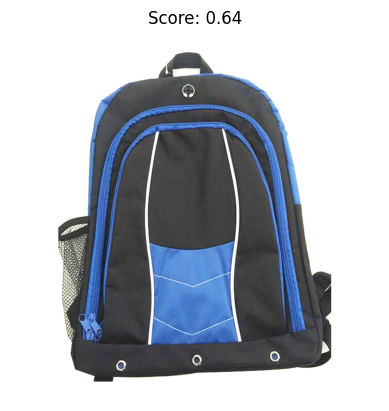

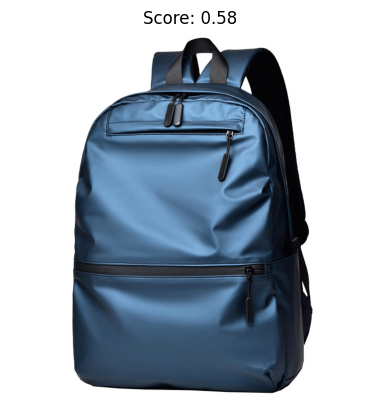

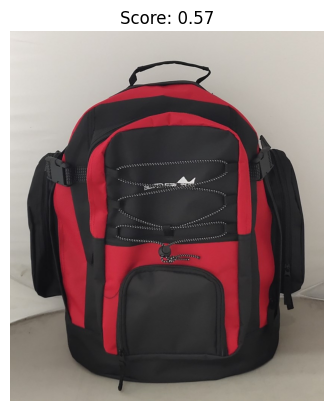

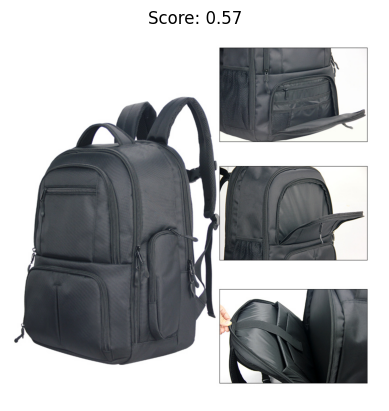

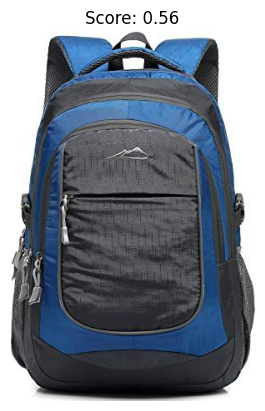

In [46]:
show_results(results, top_k=5)

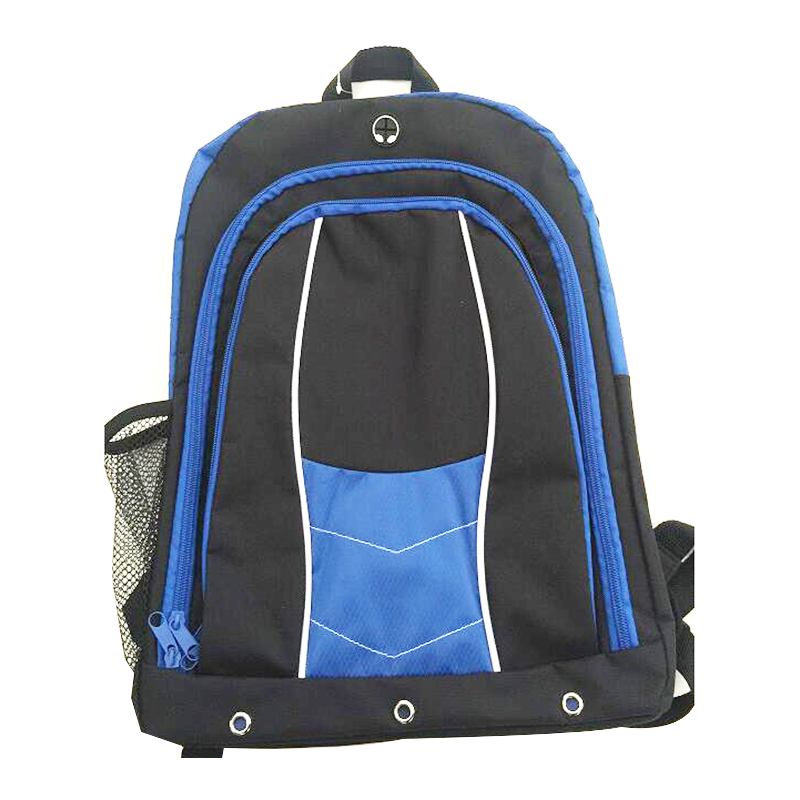

In [ ]:
#cheking if the image is right

from PIL import Image

Image.open(r"D:\Lost_and_Found\data\images\bags\000001.jpg")

In [47]:
#PRECOMPUTE & STORE EMBEDDINGS

import numpy as np

image_embeddings = []
text_embeddings = []
image_paths = []

for item in items:
    img_path = r"D:\Lost_and_Found\data\images/" + item["image"]

    try:
        img_emb = get_image_embedding(img_path)
        text_emb = get_text_embedding(item["text"])

        image_embeddings.append(img_emb)
        text_embeddings.append(text_emb)
        image_paths.append(item["image"])

    except:
        continue

# Convert to numpy
image_embeddings = np.array(image_embeddings)
text_embeddings = np.array(text_embeddings)

# Save
np.save("image_embeddings.npy", image_embeddings)
np.save("text_embeddings.npy", text_embeddings)
np.save("image_paths.npy", image_paths)

In [37]:
!pip install faiss-cpu

   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.9 MB 108.9 kB/s eta 0:02:54
   ---------------------------------------- 0.0/18.9 MB 195.7 kB/s eta 0:01:37
   ---------------------------------------- 0.0/18.9 MB 195.7 kB/s eta 0:01:37
   ---------------------------------------- 0.1/18.9 MB 231.0 kB/s eta 0:01:22
   ---------------------------------------- 0.1/18.9 MB 275.8 kB/s eta 0:01:09
   ---------------------------------------- 0.1/18.9 MB 312.2 kB/s eta 0:01:01
   ---------------------------------------- 0.1/18.9 MB 340.5 kB/s eta 0:00:56
   ---------------------------------------- 0.2/18.9 MB 339.7 kB/s eta 0:00:56
   ---------------

In [48]:
#USE FAISS (SUPER FAST SEARCH - Instead of looping through all items)

import faiss

dim = image_embeddings.shape[1]

index = faiss.IndexFlatL2(dim)
index.add(image_embeddings)

In [49]:
query_img = r"D:\Lost_and_Found\data\images\bags\000001.jpg"

query = get_image_embedding(query_img)

D, I = index.search(query.reshape(1, -1), k=5)

for idx in I[0]:
    print(image_paths[idx])

bags/000001.jpg
bags/000013.jpg
bags/000011.jpg
bags/000010.jpg
bags/000009.jpg


In [50]:
#IMPROVE SCORING by adding location, time, etc

def final_score(img_sim, text_sim, loc_sim=0, time_sim=0):
    return 0.5*img_sim + 0.3*text_sim + 0.1*loc_sim + 0.1*time_sim

In [51]:
#FUNCTION FOR BACKEND

def search_item(image_path, text):
    return top_results

In [52]:
faiss.write_index(index, "faiss_index.bin")

{'image': 'bottles/000001.jpg', 'score': 0.7029685974121094}
{'image': 'bottles/000002.jpg', 'score': 0.6618316471576691}
{'image': 'bottles/000017.jpg', 'score': 0.6558495759963989}
{'image': 'bottles/000012.jpg', 'score': 0.6393173038959503}
{'image': 'bottles/000008.jpg', 'score': 0.6141913831233978}
{'image': 'bottles/000011.jpg', 'score': 0.6119650304317474}
{'image': 'bottles/000013.jpg', 'score': 0.6089953184127808}
{'image': 'bottles/000016.jpg', 'score': 0.6015061438083649}
{'image': 'bottles/000010.jpg', 'score': 0.5939835608005524}
{'image': 'bottles/000005.jpg', 'score': 0.5845763087272644}
{'image': 'bottles/000004.jpg', 'score': 0.5820879340171814}
{'image': 'bottles/000009.jpg', 'score': 0.5790968835353851}
{'image': 'bottles/000006.jpg', 'score': 0.5770423412322998}
{'image': 'bottles/000003.jpg', 'score': 0.5701515674591064}
{'image': 'bottles/000018.jpg', 'score': 0.5694547295570374}
{'image': 'bottles/000019.jpg', 'score': 0.5616312026977539}
{'image': 'bottles/00000

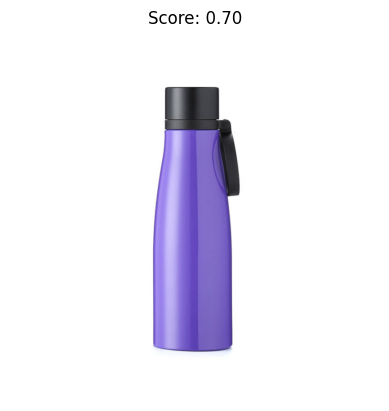

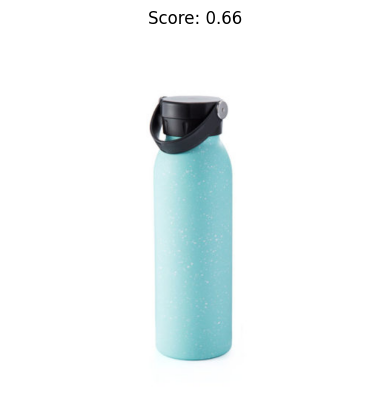

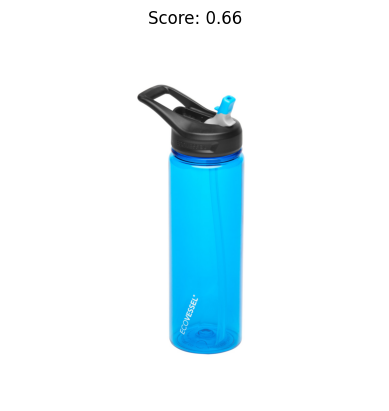

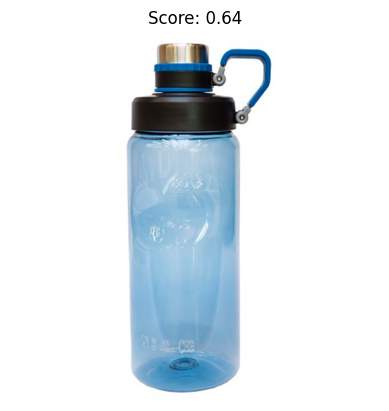

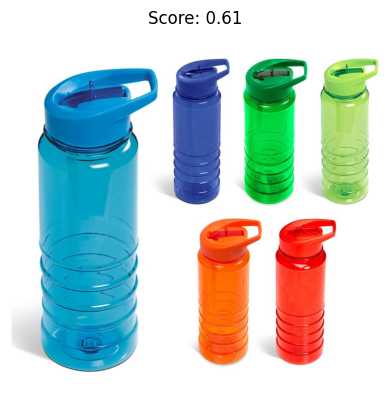

In [54]:
#Testing the model

results = find_matches(
    r"D:\Lost_and_Found\data\images\bottles\000001.jpg",
    "blue bottle", category="bottles"
)

for r in results[:]:
    print(r)
    
show_results(results, top_k=5)